Data collection

In [14]:
import pandas as pd

# Load dataset
df = pd.read_csv('daily_food_delivery_orders.csv')

# Define variables
X = df.drop(columns=['delivery_time_minutes'])
y = df['delivery_time_minutes']

Data Cleaning

In [15]:
import numpy as np

# Remove duplicates
df.drop_duplicates(inplace=True)

# Fill missing values with mean
df.fillna(df.mean(numeric_only=True), inplace=True)

# Remove outliers using IQR
Q1 = df.select_dtypes(include=np.number).quantile(0.25)
Q3 = df.select_dtypes(include=np.number).quantile(0.75)
IQR = Q3 - Q1

df = df[~((df.select_dtypes(include=np.number) < (Q1 - 1.5 * IQR)) |
          (df.select_dtypes(include=np.number) > (Q3 + 1.5 * IQR))).any(axis=1)]

Treating the Categorical Variables

In [16]:
from sklearn.preprocessing import LabelEncoder

cat_cols = ['restaurant_type', 'payment_method', 'order_status']

for col in cat_cols:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])

Spiliting the dataset

In [17]:
from sklearn.model_selection import train_test_split

X = df.drop(columns=['delivery_time_minutes'])
y = df['delivery_time_minutes']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

Featuring the Datset

In [18]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder

# 1. Drop columns that should NOT be used
df = df.drop(columns=[col for col in ['order_id', 'order_date'] if col in df.columns])

# 2. Encode categorical variables safely
cat_cols = df.select_dtypes(include='object').columns

for col in cat_cols:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col].astype(str))

# 3. Define variables
X = df.drop(columns=['delivery_time_minutes'])
y = df['delivery_time_minutes']

# 4. Split dataset
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# 5. Apply scaling
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

Building the Regression Model - Loading and Preprocessing the Data

In [19]:
import pandas as pd
import numpy as np

# Load dataset
df = pd.read_csv('daily_food_delivery_orders.csv')

# Remove unnecessary columns
df = df.drop(columns=[col for col in ['order_id', 'order_date'] if col in df.columns])

# Handle missing values
df.fillna(df.mean(numeric_only=True), inplace=True)

Building the Regression Model - Detecting and Removing Outliers

In [21]:
Q1 = df.select_dtypes(include=np.number).quantile(0.25)
Q3 = df.select_dtypes(include=np.number).quantile(0.75)
IQR = Q3 - Q1

df = df[~((df.select_dtypes(include=np.number) < (Q1 - 1.5 * IQR)) |
          (df.select_dtypes(include=np.number) > (Q3 + 1.5 * IQR))).any(axis=1)]

Building the Regression Model - Splitting the Data

In [22]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

# Encode categorical variables
cat_cols = df.select_dtypes(include='object').columns

for col in cat_cols:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col].astype(str))

# Define variables
X = df.drop(columns=['delivery_time_minutes'])
y = df['delivery_time_minutes']

# Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

Building the Regression Model - Applying Regression Models

In [24]:
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.metrics import mean_squared_error, r2_score

# Scaling
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Linear Regression
lr = LinearRegression().fit(X_train, y_train)
pred_lr = lr.predict(X_test)

# Polynomial Regression
poly = PolynomialFeatures(degree=2)
X_poly_train = poly.fit_transform(X_train)
X_poly_test = poly.transform(X_test)

pr = LinearRegression().fit(X_poly_train, y_train)
pred_pr = pr.predict(X_poly_test)

# Ridge
ridge = Ridge().fit(X_train, y_train)
pred_ridge = ridge.predict(X_test)

# Lasso
lasso = Lasso(max_iter=5000).fit(X_train, y_train)
pred_lasso = lasso.predict(X_test)

# Elastic Net
elastic = ElasticNet(max_iter=5000).fit(X_train, y_train)
pred_elastic = elastic.predict(X_test)

Building the Regression Model - Evaluating Models

In [25]:
models = {
    "Linear": pred_lr,
    "Polynomial": pred_pr,
    "Ridge": pred_ridge,
    "Lasso": pred_lasso,
    "Elastic": pred_elastic
}

for name, pred in models.items():
    print(name)
    print("MSE:", mean_squared_error(y_test, pred))
    print("R2:", r2_score(y_test, pred))
    print()

Linear
MSE: 488.88436282610604
R2: -0.01598385365026611

Polynomial
MSE: 505.34844959713
R2: -0.050198992436382595

Ridge
MSE: 488.8804764062681
R2: -0.015975777016804305

Lasso
MSE: 483.15511780086285
R2: -0.004077519797400342

Elastic
MSE: 484.4744627330783
R2: -0.00681934025730957



Building the Regression Model - Printing the Regression Equation

In [26]:
print("Intercept:", pr.intercept_)
print("Coefficients:", pr.coef_)

Intercept: 52.38617283429519
Coefficients: [-9.67061438e-18  3.68386776e-01 -5.29747184e-01  2.94043032e-02
 -6.71955899e-01  3.49566597e-01  1.05426295e+00 -3.11807805e-01
 -2.79277575e-01  6.72814641e-02 -6.67364754e-01 -1.02582258e-02
 -1.84948528e-01 -8.70283840e-02 -6.70895354e-01 -3.04343737e-01
 -6.63855786e-01 -3.98764037e-02  2.74796619e-01 -1.17174852e-01
 -9.27831260e-02  4.77408688e-01  1.34735016e+00  3.03307705e-01
 -4.71483360e-02  4.21834545e-01 -6.96269901e-01  1.12463737e-01
  1.02110006e+00  1.23757789e-01  5.04488564e-02 -1.94020284e-01
  3.55333693e-01  5.37445562e-02 -8.61432678e-01 -1.15882128e-01]


Building the Regression Model - Visualization

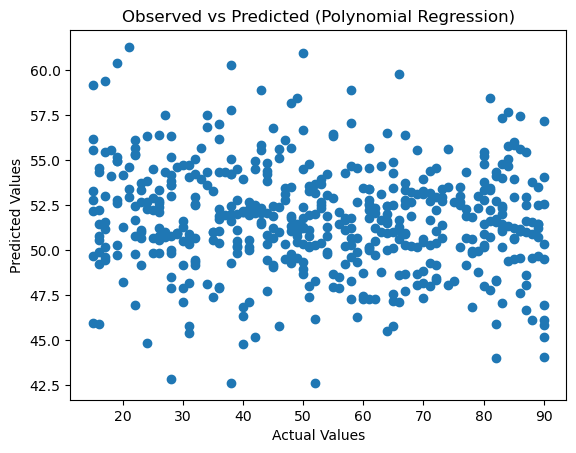

In [27]:
import matplotlib.pyplot as plt

plt.scatter(y_test, pred_pr)
plt.xlabel('Actual Values')
plt.ylabel('Predicted Values')
plt.title('Observed vs Predicted (Polynomial Regression)')
plt.show()

Classification Model

In [2]:
import pandas as pd
import numpy as np

# =========================
# 1. LOAD DATASET
# =========================
df = pd.read_csv('daily_food_delivery_orders.csv')

print("First 5 rows:")
print(df.head())

print("\nColumn names:")
print(df.columns)

# =========================
# 2. DATA PREPROCESSING
# =========================

# Remove columns that are not useful for prediction
df = df.drop(columns=["order_id", "order_date"])

# Separate target before encoding
y = df["order_status"]
X = df.drop(columns=["order_status"])

# Convert categorical columns into numeric using one-hot encoding
X = pd.get_dummies(X, drop_first=True)

print("\nProcessed feature columns:")
print(X.columns)

# =========================
# 3. TRAIN-TEST SPLIT
# =========================
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# =========================
# 4. FEATURE SCALING
# =========================
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# =========================
# 5. BUILD CLASSIFICATION MODELS
# =========================
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

models = {
    "Logistic Regression": LogisticRegression(max_iter=2000),
    "KNN": KNeighborsClassifier(),
    "SVM": SVC(),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42)
}

# =========================
# 6. TRAIN AND EVALUATE
# =========================
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

results = []

for name, model in models.items():
    # Decision Tree and Random Forest do not require scaling,
    # but using scaled data here is fine for consistency
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)

    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, average="weighted", zero_division=0)
    recall = recall_score(y_test, y_pred, average="weighted", zero_division=0)
    f1 = f1_score(y_test, y_pred, average="weighted", zero_division=0)

    results.append([name, accuracy, precision, recall, f1])

# =========================
# 7. SHOW RESULTS TABLE
# =========================
results_df = pd.DataFrame(
    results,
    columns=["Model", "Accuracy", "Precision", "Recall", "F1-score"]
)

results_df = results_df.sort_values(by="F1-score", ascending=False)

print("\nClassification Model Comparison:")
print(results_df)

# =========================
# 8. BEST MODEL
# =========================
best_model = results_df.iloc[0]

print("\nBest Model:")
print(best_model)

# =========================
# 9. NUMBER OF ELEMENTS IN EACH CATEGORY
# =========================
print("\nNumber of elements in each target category:")
print(y.value_counts())

# =========================
# 10. OPTIONAL: DETAILED REPORT FOR BEST MODEL
# =========================
from sklearn.metrics import classification_report

best_model_name = best_model["Model"]
best_model_object = models[best_model_name]
best_model_object.fit(X_train_scaled, y_train)
best_y_pred = best_model_object.predict(X_test_scaled)

print(f"\nClassification Report for {best_model_name}:")
print(classification_report(y_test, best_y_pred, zero_division=0))

First 5 rows:
   order_id  order_date  customer_age restaurant_type  order_value  \
0         1  2024-11-05            62          Indian       497.51   
1         2  2024-08-20            35          Bakery       232.32   
2         3  2024-02-28            34         Italian       540.82   
3         4  2024-05-26            65            Cafe      1197.99   
4         5  2024-09-21            40          Indian       947.03   

   delivery_distance_km  delivery_time_minutes payment_method  \
0                 11.07                     79            UPI   
1                  5.83                     69         Wallet   
2                  3.61                     70         Wallet   
3                  3.66                     18           Card   
4                 12.08                     57            UPI   

   delivery_partner_rating order_status  
0                      3.9    Cancelled  
1                      2.7    Cancelled  
2                      3.4    Cancelled  
3     

Cluster analysis

Current Working Directory: C:\Users\97155\CDS2413\project
   order_id  order_date  customer_age restaurant_type  order_value  \
0         1  2024-11-05            62          Indian       497.51   
1         2  2024-08-20            35          Bakery       232.32   
2         3  2024-02-28            34         Italian       540.82   
3         4  2024-05-26            65            Cafe      1197.99   
4         5  2024-09-21            40          Indian       947.03   

   delivery_distance_km  delivery_time_minutes payment_method  \
0                 11.07                     79            UPI   
1                  5.83                     69         Wallet   
2                  3.61                     70         Wallet   
3                  3.66                     18           Card   
4                 12.08                     57            UPI   

   delivery_partner_rating order_status  
0                      3.9    Cancelled  
1                      2.7    Cancelled  
2   

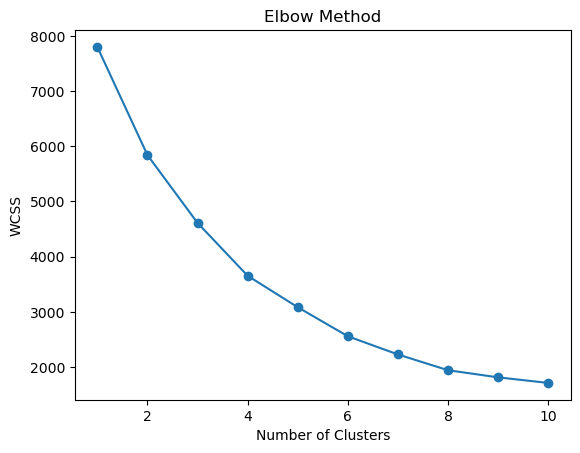

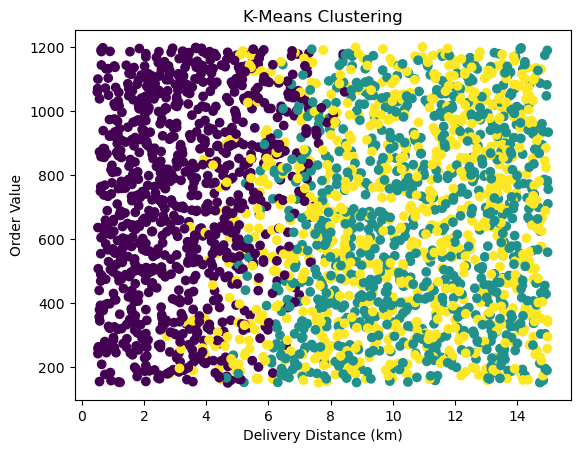


Number of elements in each cluster:
Cluster
0    924
2    843
1    833
Name: count, dtype: int64


In [3]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
import os

# -------------------------
# 1. CHECK CURRENT DIRECTORY (optional)
# -------------------------
print("Current Working Directory:", os.getcwd())

# -------------------------
# 2. LOAD DATASET
# -------------------------
df = pd.read_csv('daily_food_delivery_orders.csv')

# Preview data
print(df.head())

# -------------------------
# 3. SELECT FEATURES
# -------------------------
features = df[['delivery_distance_km', 'order_value', 'delivery_partner_rating']]

# -------------------------
# 4. HANDLE MISSING VALUES
# -------------------------
features = features.fillna(features.mean())

# -------------------------
# 5. FEATURE SCALING
# -------------------------
scaler = StandardScaler()
scaled_features = scaler.fit_transform(features)

# -------------------------
# 6. ELBOW METHOD (FIND BEST K)
# -------------------------
wcss = []

for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, random_state=42, n_init=10)
    kmeans.fit(scaled_features)
    wcss.append(kmeans.inertia_)

# Plot Elbow Graph
plt.figure()
plt.plot(range(1, 11), wcss, marker='o')
plt.xlabel('Number of Clusters')
plt.ylabel('WCSS')
plt.title('Elbow Method')
plt.show()

# -------------------------
# 7. APPLY K-MEANS (K = 3)
# -------------------------
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
clusters = kmeans.fit_predict(scaled_features)

# Add cluster column
df['Cluster'] = clusters

# -------------------------
# 8. VISUALIZE CLUSTERS
# -------------------------
plt.figure()
plt.scatter(df['delivery_distance_km'], df['order_value'], c=df['Cluster'])
plt.xlabel('Delivery Distance (km)')
plt.ylabel('Order Value')
plt.title('K-Means Clustering')
plt.show()

# -------------------------
# 9. SHOW CLUSTER COUNTS
# -------------------------
print("\nNumber of elements in each cluster:")
print(df['Cluster'].value_counts())